Exercise 1 Classifying Breast Cancer

In [4]:
import numpy as np
import pandas as pd

In [8]:
# data input
csvname = 'breast_cancer_data.csv'
data1 = np.loadtxt(csvname, delimiter = ',')
# get input and output of dataset
x = data1[:-1,:]
y = data1[-1:,:]

In [12]:
from autograd import grad 

import autograd.numpy as np 

def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]           # container for weight history
    cost_history = [g(w)]          # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)
        

        # take gradient descent step
        w = w - alpha*grad_eval
        if np.any(np.isnan(w)) :
            break
        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    
    return cost_history, weight_history

In [10]:
# compute linear combination of input points
def model(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return a.T
# an implementation of the softmax cost
def softmax(w):
# compute the least squares cost
    cost = np.sum(np.log(1 + np.exp(-y*model(x,w))))
    return cost/float(np.size(y))
# an implementation of the perceptron cos
def perceptron(w):
    a = model(x,w)
    m = y * a
    loss = np.maximum(0, -m)
    cost  = np.sum(loss) / np.size(y)

    return cost
    
    



In [22]:
max_its = 1000
w = 0.1*np.random.randn(9,1) 
percepAlpha = 0.1
softAlpha = 1.0

perceptCost, percepWeight = gradient_descent(perceptron, percepAlpha, max_its,  w)
softCost, softWeight = gradient_descent(softmax, softAlpha, max_its, w)

def miscount(w,x,y) :

    a = model(x,w)
    m = y*a
    count  = np.sum(m <=0)

    return count 

percep_miscount_hist = [miscount(v, x, y) for v in percepWeight]
soft_miscount_hist = [miscount(v, x, y) for v in softWeight]

print("Perceptron min miscount:", min(percep_miscount_hist))
print("Softmax min miscount:", min(soft_miscount_hist))


Perceptron min miscount: 20
Softmax min miscount: 21


In [ ]:
import sys
import matplotlib.pyplot as plt
from MLRPlotting import static_plotter
static_plotter = static_plotter.Visualizer();


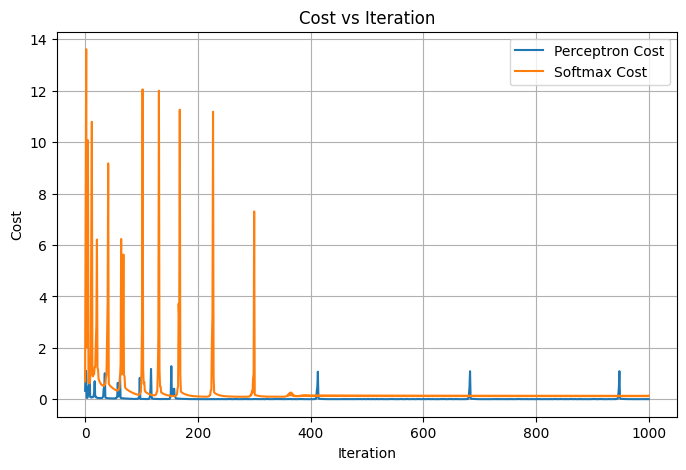

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(perceptCost, label='Perceptron Cost')
plt.plot(softCost, label='Softmax Cost')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.legend()
plt.grid(True)

plt.show()


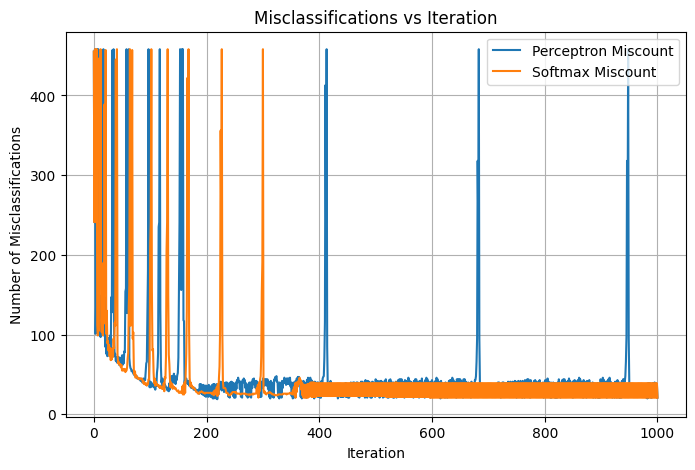

In [21]:
plt.figure(figsize=(8,5))

plt.plot(percep_miscount_hist, label='Perceptron Miscount')
plt.plot(soft_miscount_hist, label='Softmax Miscount')

plt.xlabel('Iteration')
plt.ylabel('Number of Misclassifications')
plt.title('Misclassifications vs Iteration')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def miscount_maligant(x,w,y) :
    a= model(x,w)
    m = y * a

    malignant = (y == -1)
    missclassified = (m <= 0)

    return np.sum(malignant  & missclassified)

In [ ]:
a=np.argwhere(y>0.9)
b=np.argwhere(y<-0.9)
yc=np.arange(699)
yc[a]=1
yc[b]=0

In [ ]:
# define sigmoid function
def sigmoid(t):
    return 1/(1 + np.exp(-t))
# the convex cross-entropy cost function
lam = 2*10**(-3)
def cross_entropy(w):
# compute sigmoid of model
    a = sigmoid(model(x,w))
# compute cost of label 0 points
    ind = np.argwhere(yc == 0)
    cost = -np.sum(np.log(1 - a[:,ind]))
# add cost on label 1 points
    ind = np.argwhere(yc==1)
    cost -= np.sum(np.log(a[:,ind]))
# add regularizer
    cost += lam*np.sum(w[1:]**2)
# compute cross-entropy
    return cost/float(np.size(yc))


In [ ]:
alpha = 0.6
w = 0.1*np.random.randn(5,1) 
max_its = 1000

log_cost, log_weight = gradient_descent(cross_entropy, alpha, max_its, w)

def log_missclass(w, x, yc) :
    a = sigmoid(model(x,w))

    y_pred = (a >= 0.5)

    return np.sum(y_pred != yc)

Exercise 2 Spam Detection


In [ ]:
# data input
csvname = 'spambase_data.csv'
data1 = np.loadtxt(csvname, delimiter = ',')
# get input and output of dataset
x = data1[:-1,:]
y = data1[-1:,:]

In [23]:
def standard_normalizer(x):
    # compute the mean and standard deviation of the input
    x_means = np.nanmean(x,axis = 1)[:,np.newaxis]
    x_stds = np.nanstd(x,axis = 1)[:,np.newaxis]
    # check to make sure that x_stds > small threshold, for those not
    # divide by 1 instead of original standard deviation
    ind = np.argwhere(x_stds < 10**(-2))
    if len(ind) > 0:
        ind = [v[0] for v in ind] # Just keep the row index
        adjust = np.zeros((x_stds.shape))
        adjust[ind] = 1.0
        x_stds += adjust
    # fill in any nan values with means
    ind = np.argwhere(np.isnan(x) == True)
    for i in ind:
        x[i[0],i[1]] = x_means[i[0]]

    # create standard normalizer function
    normalizer = lambda data: (data - x_means)/x_stds
    # create inverse standard normalizer
    inverse_normalizer = lambda data: data*x_stds + x_means
    # return normalizer
    return normalizer,inverse_normalizer

In [28]:
normalizer, inverse_normalizer = standard_normalizer(x)
x = normalizer(x)

N = x.shape[0]
w = 0.1*np.random.randn(N+1,1)
max_its = 1000
alphaS = 1.0
alphaP = 0.1

perceptCost, percepWeight = gradient_descent(perceptron, alphaP, max_its, w)
softCost, softWeight = gradient_descent(softmax, alphaS, max_its, w)

def miscount(w,x,y) :

    a = model(x,w)
    m = y*a
    count  = np.sum(m <=0)

    return count 

percep_miscount_hist = [miscount(v, x, y) for v in percepWeight]
soft_miscount_hist = [miscount(v, x, y) for v in softWeight]




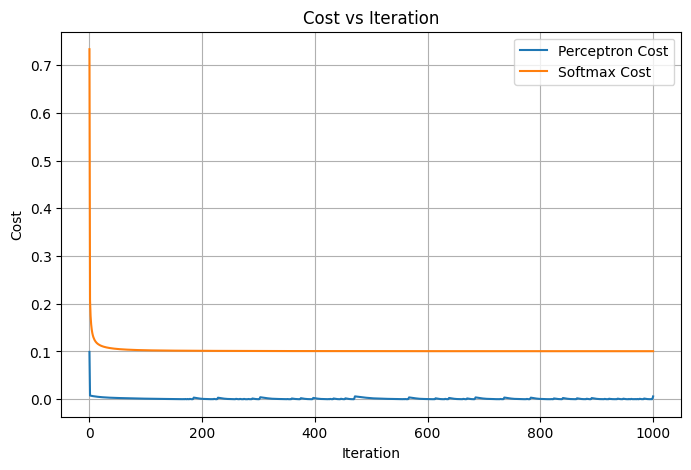

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(perceptCost, label='Perceptron Cost')
plt.plot(softCost, label='Softmax Cost')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.legend()
plt.grid(True)

plt.show()


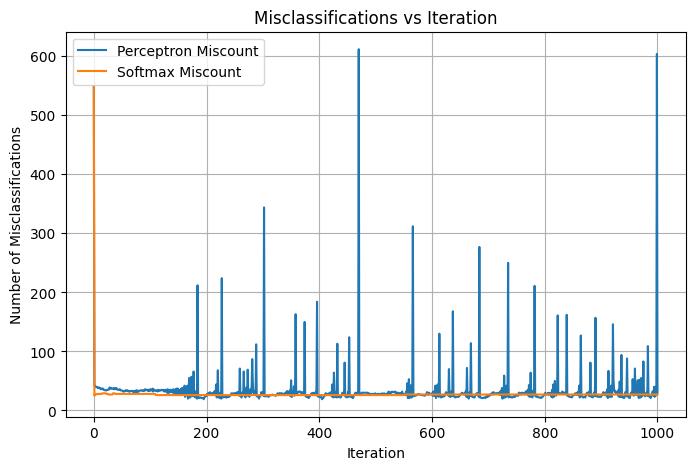

In [30]:
plt.figure(figsize=(8,5))

plt.plot(percep_miscount_hist, label='Perceptron Miscount')
plt.plot(soft_miscount_hist, label='Softmax Miscount')

plt.xlabel('Iteration')
plt.ylabel('Number of Misclassifications')
plt.title('Misclassifications vs Iteration')
plt.legend()
plt.grid(True)

plt.show()

After doing standard normalization on both cost functions, a more table behaviour is present. the descent is smoother and there are less oscilations in the missclassifications. conversely, the perceptron shows a more fluctuations and large spikes in the missclassification process. largely due to its loss validation strcutre. softmaxx, displays more consistent and table convergence than perceptron. 

In [31]:
min_percep = min(percep_miscount_hist)
min_soft = min(soft_miscount_hist)

P = x.shape[1]

acc_percep = (P - min_percep) / P
acc_soft = (P - min_soft) / P

acc_percep * 100
acc_soft * 100

print(f" perceptron accuracy: {acc_percep} softmax accuracy: {acc_soft}")



 perceptron accuracy: 0.9728183118741058 softmax accuracy: 0.9642346208869814


the perceptron did achieve a slightly higher accuract than the softmax, though the difference is small. since both methods optmizie surrogate losses rather then tacking the classification error directly, it can be that one is better on the given training set. the softmax gives a smoother optimization, while the perceptron has more aggresive updates which can lead to slightly lower training error in some cases. 

In [ ]:
best_w = softWeight[np.argmin(soft_miscount_hist)]

a = model(x, best_w)
y_pred = np.sign(a)

TP = np.sum((y==1) & (y_pred == 1))
TN = np.sum((y== -1) & (y_pred == -1))
FP = np.sum((y== -1) & (y_pred == 1))
FN = np.sum((y==1) & (y_pred == -1))

confusion_matrix = np.array([[TP, FN], [FP, TN]])

Exercise 3 Accessing UC Irvine Machine Learning Repository

In [ ]:
from ucimlrepo import fetch_ucirepo

breastcancer = fetch_ucirepo(id=15)

X = breastcancer.data.features
y = breastcancer.data.targets

print(X.columns)

X = X.drop(columns=['Single_epithelial_cell_size'])

Index(['Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses'],
      dtype='object')


In [ ]:
print(y.head())
y = y.replace({2: 1, 4: -1})

   Class
0      2
1      2
2      2
3      2
4      2


Exercise 4 Credit Check

In [37]:
# data input
csvname = 'credit_dataset.csv'
data1 = np.loadtxt(csvname, delimiter = ',')
# get input and output of dataset
x = data1[:-1,:]
y = data1[-1:,:]

x_means = np.mean(x, axis=1)[:, np.newaxis]
x_stds = np.std(x, axis=1)[:, np.newaxis]

x = (x - x_means) / x_stds
N = x.shape[0]

In [40]:
max_its = 1000
w = 0.1*np.random.randn(N+1,1)
alpha = 0.1 

perceptCost, percepWeight = gradient_descent(perceptron, alpha, max_its, w)

def miscount(w,x,y) :

    a = model(x,w)
    m = y*a
    count  = np.sum(m <=0)

    return count 

percep_miscount_hist = [miscount(v, x, y) for v in percepWeight]





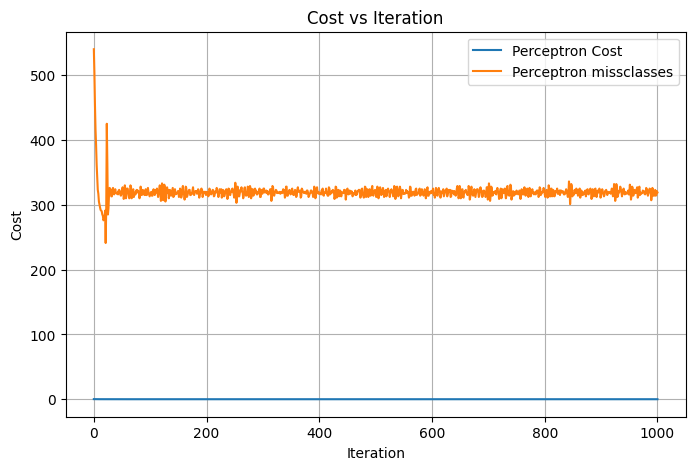

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(perceptCost, label='Perceptron Cost')
plt.plot(percep_miscount_hist, label='Perceptron missclasses')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.legend()
plt.grid(True)


In [42]:
min_mis = min(percep_miscount_hist)
accuracy = (x.shape[1] - min_mis) / x.shape[1]
print(f"Accuracy: {accuracy}")

Accuracy: 0.759


In [ ]:
best_w = softWeight[np.argmin(soft_miscount_hist)]

a = model(x, best_w)
y_pred = np.sign(a)

TP = np.sum((y==1) & (y_pred == 1))
TN = np.sum((y== -1) & (y_pred == -1))
FP = np.sum((y== -1) & (y_pred == 1))
FN = np.sum((y==1) & (y_pred == -1))

confusion_matrix = np.array([[TP, FN], [FP, TN]])

Exercise 5 3-Class, classification


In [44]:
lam = 10**-5 # our regularization paramter
def multiclass_perceptron(w):
# pre-compute predictions on all points
    all_evals = model(x,w)
# compute maximum across data points
    a = np.max(all_evals,axis = 0)
# compute cost in compact form using numpy broadcasting
    b = all_evals[y.astype(int).flatten(),np.arange(np.size(y))]
    cost = np.sum(a - b)
# add regularizer
    cost = cost + lam*np.linalg.norm(w[1:,:],'fro')**2
# return average
    return cost/float(np.size(y))




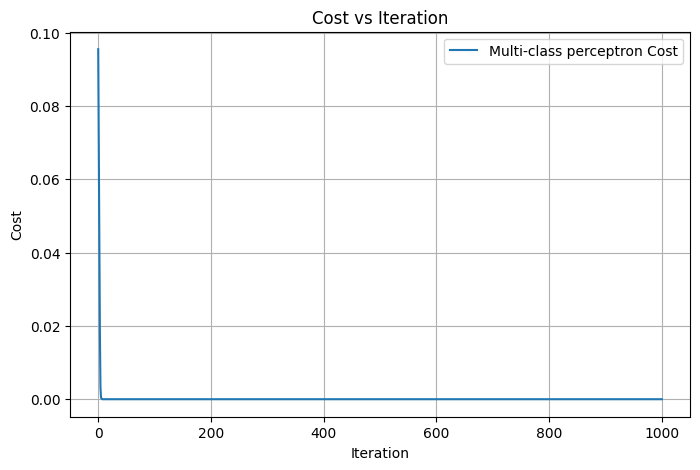

In [46]:
csvname = '3class_data.csv'
data1 = np.loadtxt(csvname, delimiter = ',')
# get input and output of dataset
x = data1[:-1,:]
y = data1[-1:,:]


max_its = 1000
alpha = 0.1 
w = 0.1*np.random.randn(3,3)

multipercep_cost, mulitpercep_weight = gradient_descent(multiclass_perceptron, alpha, max_its, w)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(multipercep_cost, label='Multi-class perceptron Cost')

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.legend()
plt.grid(True)


In [48]:
best_w = mulitpercep_weight[np.argmin(multipercep_cost)]

x1 = x[0,:]
x2 = x[1,:]

xx, yy = np.meshgrid(np.linspace(min(x1)-1, max(x1) + 1, 300), 
                     np.linspace(min(x2)-1, max(x2) + 1, 300))

grid = np.vstack((np.ones(xx.size),
                  xx.ravel(), 
                  yy.ravel()))

scores = best_w.T @ grid
preds = np.argmax(scores, axis=0)

Z = preds.reshape(xx.shape)

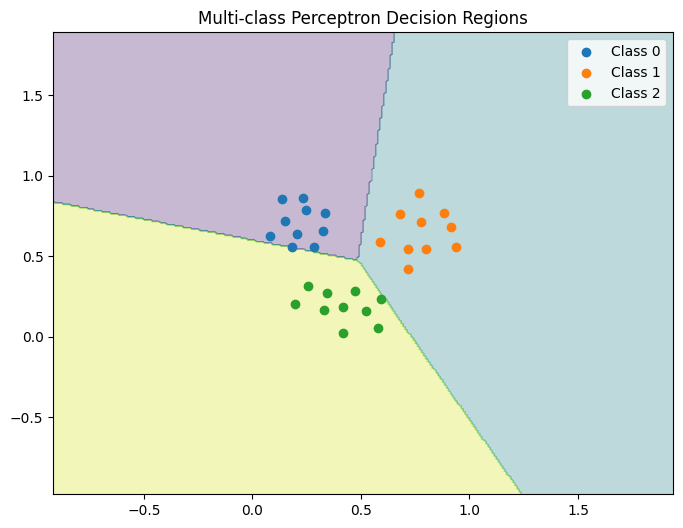

In [49]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

y_flat = y.flatten()
plt.scatter(x1[y_flat==0], x2[y_flat==0], label="Class 0")
plt.scatter(x1[y_flat==1], x2[y_flat==1], label="Class 1")
plt.scatter(x1[y_flat==2], x2[y_flat==2], label="Class 2")

plt.legend()
plt.title("Multi-class Perceptron Decision Regions")
plt.show()